In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils 


import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore",category=DeprecationWarning)
    import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

import seaborn as sns

warnings.filterwarnings("ignore", 
    ".*Consider increasing the value of the `num_workers` argument*")
warnings.filterwarnings("ignore", 
    ".*Set a lower value for log_every_n_steps "
    "if you want to see logs for the training epoch")

# local imports
from rosetta_db import get_sqlite_dbcon
import utils 
from train_vaes_phils_nb import get_aaindex_embedding

In [2]:
# setup torchtext vocab to map AAs to indices, usage is aa2ind(list(AAsequence))
AAs = 'ACDEFGHIKLMNPQRSTVWY'
aa2ind_dict = {a:i for i, a in enumerate(AAs)}

In [3]:
class RosettaSQLdf(torch.utils.data.Dataset):
   
    def __init__(self, df, parent_seq, dtype=torch.float32):
        self.df = df
        self.dtype = dtype
        self.parent_seq = parent_seq
        self.parent_enc = list(map(aa2ind_dict.get, self.parent_seq))
        
    def __getitem__(self, idx):
        energies = torch.tensor(self.df.iloc[idx][1:-1], dtype=self.dtype)
        seq_list = utils.expand_mut_str_list_to_list(
                self.df.iloc[idx, -1], self.parent_enc, encoder=aa2ind_dict.get,
                split_mut_char=".", offset=1)
        seq = torch.tensor(seq_list, dtype=torch.int)
        return seq, energies

    def __len__(self):
        return len(self.df)

In [4]:
class RosettaEnergiesDataModule(pl.LightningDataModule):
    
    def __init__(self, parent = "2D", batch_size=32, dtype=torch.float32, num_workers=1):
        super().__init__()
        self.parent = parent
        self.batch_size = batch_size
        self.dtype = dtype
        self.num_workers = num_workers
        
        # read sequence and encode
        self.parent_seq = utils.get_parent_seq(parent=self.parent)
        self.slen = len(self.parent_seq)
        #self.parent_enc = list(map(aa2ind_dict.get, self.parent))

        # read in data from database
        db_con = get_sqlite_dbcon(parent=self.parent)
        self.df = pd.read_sql("select * from relaxed_scores limit 100000", db_con)
        
        del self.df["description"]
        del self.df["dslf_fa13"] # disulfide bond energy
        
        # number of parameters to predict
        self.nparam = len(self.df.columns) - 2 # dropping first (total energy) and last column (variant)

        
        N = len(self.df)
        train_val_test_split = [0.8, 0.1, 0.1]
        n_train_val_test = np.round(np.array(train_val_test_split)*N).astype(int)
        n_train_val_test[-1] = (N  - n_train_val_test[:-1].sum())
        self.train_idx, self.val_idx, self.test_idx = \
                data_utils.random_split(range(N),n_train_val_test)

    def prepare_data(self):
        # prepare_data is called from a single GPU. Do not use it to assign state (self.x = y)
        # use this method to do things that might write to disk or that need to be done only from a single process
        # in distributed settings.
        pass

    
    def setup(self, stage=None):
              
        # Assign train/val datasets for use in dataloaders
        if stage == 'fit' or stage is None:
            self.train_data = RosettaSQLdf(self.df.iloc[list(self.train_idx),], self.parent_seq)
            self.val_data = RosettaSQLdf(self.df.iloc[list(self.val_idx),], self.parent_seq)
            
        # Assign test dataset for use in dataloader(s)
        if stage == 'test' or stage is None:
            self.test_data = RosettaSQLdf(self.df.iloc[list(self.test_idx),], self.parent_seq)

    def train_dataloader(self):
        return data_utils.DataLoader(self.train_data, batch_size=self.batch_size, 
                                         shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return data_utils.DataLoader(self.val_data, batch_size=self.batch_size,
                                        num_workers=self.num_workers)

    def test_dataloader(self):
        return data_utils.DataLoader(self.test_data, batch_size=self.batch_size, 
                                        num_workers=self.num_workers)
    
    def predict_dataloader(self):
        return self.test_dataloader()

rd = RosettaEnergiesDataModule(parent="2D")

# rd.setup()
# for x in rd.test_dataloader():
#     break
# print(x[0].shape)
# print(x[1].shape)

In [5]:
class RosettaEnergyPrediction(pl.LightningModule):
    
    def __init__(self, slen, nparam, embed_ncomp=0, embed_freeze=True, learning_rate=0.01, ):
        
        super().__init__()

        ## GENERAL INPUT PARAMETERS
        self.slen = slen # sequence length
        self.nparam = nparam # number of energy terms to predict
        self.q = 20 # amino acid alphabet_size (without gaps)
        
        self.learning_rate = learning_rate
        
        if embed_ncomp: # if non-zero get a pretrained PCA embedding of Amino acids based on physiochemical properties
            aaindex = get_aaindex_embedding(ncomp=embed_ncomp)
            aaindex = aaindex[:-1, :] # drop the gap character
            assert(aaindex.shape[0] == self.q)
        else: # if embed_ncomp is zero then do one-hot encoding
            aaindex = torch.eye(self.q)
            
            
        self.embed = nn.Embedding.from_pretrained(aaindex, freeze=embed_freeze)
        self.edim = self.embed.embedding_dim # dimensions of AA embedding
       
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(self.edim*self.slen, self.nparam)
        
        # save hyperparameters for logging 
        self.save_hyperparameters()
        
    def forward(self, x):
        x = self.embed(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x
    
    def shared_step(self, batch):
        x, y = batch
        # pass through network
        out = self(x)
        
        # calculate loss
        return nn.MSELoss()(out, y)
        
    def training_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        self.log("train_loss", loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        self.log("val_loss", loss)
        return loss
    
    def test_step(self, batch, batch_idx):
        return self.shared_step(batch)
    
    def predict_step(self, batch, batch_idx):
        x, y = batch
        return self(x), y
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [6]:
dm = RosettaEnergiesDataModule(parent = "2D")

In [7]:
#model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam, embed_freeze=True, embed_ncomp=8)
model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam)

In [8]:
# train 
logger = CSVLogger('logs', name='Linear')
trainer = pl.Trainer(logger=logger
                     ,max_epochs=50
                     ,gpus=0
                     #,enable_progress_bar=False
                    )
trainer.fit(model,dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs

  | Name    | Type      | Params
--------------------------------------
0 | embed   | Embedding | 400   
1 | flatten | Flatten   | 0     
2 | linear  | Linear    | 98.3 K
--------------------------------------
98.3 K    Trainable params
400       Non-trainable params
98.7 K    Total params
0.395     Total estimated model params size (MB)


Epoch 0:  89% 2500/2813 [00:34<00:04, 71.94it/s, loss=10.6, v_num=25]   
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/313 [00:00<?, ?it/s]
Epoch 0:  89% 2508/2813 [00:34<00:04, 71.82it/s, loss=10.6, v_num=25]
Epoch 0:  89% 2516/2813 [00:35<00:04, 71.82it/s, loss=10.6, v_num=25]
Epoch 0:  90% 2524/2813 [00:35<00:04, 71.83it/s, loss=10.6, v_num=25]
Epoch 0:  90% 2532/2813 [00:35<00:03, 71.84it/s, loss=10.6, v_num=25]
Epoch 0:  90% 2540/2813 [00:35<00:03, 71.85it/s, loss=10.6, v_num=25]
Epoch 0:  91% 2548/2813 [00:35<00:03, 71.88it/s, loss=10.6, v_num=25]
Epoch 0:  91% 2556/2813 [00:35<00:03, 71.90it/s, loss=10.6, v_num=25]
Epoch 0:  91% 2564/2813 [00:35<00:03, 71.92it/s, loss=10.6, v_num=25]
Epoch 0:  91% 2572/2813 [00:35<00:03, 71.94it/s, loss=10.6, v_num=25]
Epoch 0:  92% 2580/2813 [00:35<00:03, 71.96it/s, loss=10.6, v_num=25]
Epoch 0:  92% 2588/2813 [00:35<00:03, 71.97it/s, loss=10.6, v_num=25]
Epoch 0:  92% 2596/2813 [00:36<00:03, 71.98it/s, loss=10.6, v_num=25]
Epoch 0:  93% 26

Epoch 2: 100% 2799/2813 [00:39<00:00, 71.30it/s, loss=6.01, v_num=25]
Epoch 2: 100% 2808/2813 [00:39<00:00, 71.32it/s, loss=6.01, v_num=25]
Epoch 2: 100% 2813/2813 [00:39<00:00, 71.30it/s, loss=6.01, v_num=25]
Epoch 3:  89% 2500/2813 [00:34<00:04, 71.73it/s, loss=38.4, v_num=25]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/313 [00:00<?, ?it/s]
Epoch 3:  89% 2502/2813 [00:34<00:04, 71.55it/s, loss=38.4, v_num=25]
Epoch 3:  89% 2511/2813 [00:35<00:04, 71.51it/s, loss=38.4, v_num=25]
Epoch 3:  90% 2520/2813 [00:35<00:04, 71.51it/s, loss=38.4, v_num=25]
Epoch 3:  90% 2529/2813 [00:35<00:03, 71.52it/s, loss=38.4, v_num=25]
Epoch 3:  90% 2538/2813 [00:35<00:03, 71.46it/s, loss=38.4, v_num=25]
Validating:  12% 38/313 [00:00<00:04, 62.82it/s]
Epoch 3:  91% 2547/2813 [00:35<00:03, 71.47it/s, loss=38.4, v_num=25]
Epoch 3:  91% 2556/2813 [00:35<00:03, 71.46it/s, loss=38.4, v_num=25]
Epoch 3:  91% 2565/2813 [00:35<00:03, 71.45it/s, loss=38.4, v_num=25]
Epoch 3:  92% 2574/2813 [00:36<00:03, 71

Epoch 5:  99% 2772/2813 [00:39<00:00, 71.07it/s, loss=2.8, v_num=25]
Epoch 5:  99% 2781/2813 [00:39<00:00, 71.09it/s, loss=2.8, v_num=25]
Epoch 5:  99% 2790/2813 [00:39<00:00, 71.12it/s, loss=2.8, v_num=25]
Epoch 5: 100% 2799/2813 [00:39<00:00, 71.15it/s, loss=2.8, v_num=25]
Epoch 5: 100% 2813/2813 [00:39<00:00, 71.16it/s, loss=2.8, v_num=25]
Epoch 6:  89% 2500/2813 [00:34<00:04, 72.61it/s, loss=2.48, v_num=25]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/313 [00:00<?, ?it/s]
Epoch 6:  89% 2502/2813 [00:34<00:04, 72.40it/s, loss=2.48, v_num=25]
Epoch 6:  89% 2511/2813 [00:34<00:04, 72.36it/s, loss=2.48, v_num=25]
Epoch 6:  90% 2520/2813 [00:34<00:04, 72.37it/s, loss=2.48, v_num=25]
Epoch 6:  90% 2529/2813 [00:34<00:03, 72.38it/s, loss=2.48, v_num=25]
Epoch 6:  90% 2538/2813 [00:35<00:03, 72.40it/s, loss=2.48, v_num=25]
Epoch 6:  91% 2547/2813 [00:35<00:03, 72.43it/s, loss=2.48, v_num=25]
Epoch 6:  91% 2556/2813 [00:35<00:03, 72.46it/s, loss=2.48, v_num=25]
Epoch 6:  91% 2565/2813 

Epoch 8:  98% 2763/2813 [00:38<00:00, 72.34it/s, loss=32, v_num=25]
Validating:  84% 263/313 [00:03<00:00, 79.06it/s]
Epoch 8:  99% 2772/2813 [00:38<00:00, 72.35it/s, loss=32, v_num=25]
Epoch 8:  99% 2781/2813 [00:38<00:00, 72.38it/s, loss=32, v_num=25]
Epoch 8:  99% 2790/2813 [00:38<00:00, 72.40it/s, loss=32, v_num=25]
Epoch 8: 100% 2799/2813 [00:38<00:00, 72.42it/s, loss=32, v_num=25]
Epoch 8: 100% 2808/2813 [00:38<00:00, 72.44it/s, loss=32, v_num=25]
Epoch 8: 100% 2813/2813 [00:38<00:00, 72.41it/s, loss=32, v_num=25]
Epoch 9:  89% 2500/2813 [00:34<00:04, 71.49it/s, loss=6.91, v_num=25]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/313 [00:00<?, ?it/s]
Epoch 9:  89% 2502/2813 [00:35<00:04, 71.27it/s, loss=6.91, v_num=25]
Epoch 9:  89% 2511/2813 [00:35<00:04, 71.26it/s, loss=6.91, v_num=25]
Epoch 9:  90% 2520/2813 [00:35<00:04, 71.29it/s, loss=6.91, v_num=25]
Epoch 9:  90% 2529/2813 [00:35<00:03, 71.32it/s, loss=6.91, v_num=25]
Epoch 9:  90% 2538/2813 [00:35<00:03, 71.36it/s, loss

...

Epoch 37:  98% 2763/2813 [00:38<00:00, 71.15it/s, loss=2.28, v_num=25]
Epoch 37:  99% 2772/2813 [00:38<00:00, 71.17it/s, loss=2.28, v_num=25]
Epoch 37:  99% 2781/2813 [00:39<00:00, 71.19it/s, loss=2.28, v_num=25]
Validating:  90% 281/313 [00:03<00:00, 74.80it/s]
Epoch 37:  99% 2790/2813 [00:39<00:00, 71.21it/s, loss=2.28, v_num=25]
Epoch 37: 100% 2799/2813 [00:39<00:00, 71.23it/s, loss=2.28, v_num=25]
Epoch 37: 100% 2813/2813 [00:39<00:00, 71.21it/s, loss=2.28, v_num=25]
Epoch 38:  89% 2500/2813 [00:35<00:04, 71.01it/s, loss=26.1, v_num=25]
Validating: 0it [00:00, ?it/s]
Epoch 38:  89% 2502/2813 [00:35<00:04, 70.84it/s, loss=26.1, v_num=25]
Epoch 38:  89% 2511/2813 [00:35<00:04, 70.86it/s, loss=26.1, v_num=25]
Validating:   4% 11/313 [00:00<00:05, 54.14it/s]
Epoch 38:  90% 2520/2813 [00:35<00:04, 70.87it/s, loss=26.1, v_num=25]
Epoch 38:  90% 2529/2813 [00:35<00:04, 70.89it/s, loss=26.1, v_num=25]
Epoch 38:  90% 2538/2813 [00:35<00:03, 70.91it/s, loss=26.1, v_num=25]
Epoch 38:  91% 254

Epoch 40:  98% 2754/2813 [00:38<00:00, 71.81it/s, loss=17.3, v_num=25]
Validating:  81% 254/313 [00:03<00:00, 74.95it/s]
Epoch 40:  98% 2763/2813 [00:38<00:00, 71.81it/s, loss=17.3, v_num=25]
Epoch 40:  99% 2772/2813 [00:38<00:00, 71.83it/s, loss=17.3, v_num=25]
Epoch 40:  99% 2781/2813 [00:38<00:00, 71.82it/s, loss=17.3, v_num=25]
Epoch 40:  99% 2790/2813 [00:38<00:00, 71.84it/s, loss=17.3, v_num=25]
Epoch 40: 100% 2799/2813 [00:38<00:00, 71.85it/s, loss=17.3, v_num=25]
Epoch 40: 100% 2808/2813 [00:39<00:00, 71.86it/s, loss=17.3, v_num=25]
Epoch 40: 100% 2813/2813 [00:39<00:00, 71.82it/s, loss=17.3, v_num=25]
Epoch 41:  89% 2500/2813 [00:35<00:04, 70.01it/s, loss=3.54, v_num=25]
Validating: 0it [00:00, ?it/s]
Epoch 41:  89% 2502/2813 [00:35<00:04, 69.86it/s, loss=3.54, v_num=25]
Epoch 41:  89% 2511/2813 [00:35<00:04, 69.88it/s, loss=3.54, v_num=25]
Validating:   4% 11/313 [00:00<00:05, 53.92it/s]
Epoch 41:  90% 2520/2813 [00:36<00:04, 69.88it/s, loss=3.54, v_num=25]
Epoch 41:  90% 252

Epoch 43:  97% 2736/2813 [00:39<00:01, 69.51it/s, loss=2.93, v_num=25]
Epoch 43:  98% 2745/2813 [00:39<00:00, 69.54it/s, loss=2.93, v_num=25]
Epoch 43:  98% 2754/2813 [00:39<00:00, 69.57it/s, loss=2.93, v_num=25]
Epoch 43:  98% 2763/2813 [00:39<00:00, 69.61it/s, loss=2.93, v_num=25]
Epoch 43:  99% 2772/2813 [00:39<00:00, 69.64it/s, loss=2.93, v_num=25]
Epoch 43:  99% 2781/2813 [00:39<00:00, 69.67it/s, loss=2.93, v_num=25]
Epoch 43:  99% 2790/2813 [00:40<00:00, 69.70it/s, loss=2.93, v_num=25]
Epoch 43: 100% 2799/2813 [00:40<00:00, 69.73it/s, loss=2.93, v_num=25]
Epoch 43: 100% 2813/2813 [00:40<00:00, 69.72it/s, loss=2.93, v_num=25]
Epoch 44:  89% 2500/2813 [00:36<00:04, 68.72it/s, loss=15.3, v_num=25]
Validating: 0it [00:00, ?it/s]
Epoch 44:  89% 2502/2813 [00:36<00:04, 68.56it/s, loss=15.3, v_num=25]
Validating:   1% 2/313 [00:00<00:15, 19.70it/s]
Epoch 44:  89% 2511/2813 [00:36<00:04, 68.56it/s, loss=15.3, v_num=25]
Epoch 44:  90% 2520/2813 [00:36<00:04, 68.57it/s, loss=15.3, v_num=25

Epoch 46:  97% 2727/2813 [00:38<00:01, 71.40it/s, loss=2.12, v_num=25]
Epoch 46:  97% 2736/2813 [00:38<00:01, 71.43it/s, loss=2.12, v_num=25]
Epoch 46:  98% 2745/2813 [00:38<00:00, 71.46it/s, loss=2.12, v_num=25]
Epoch 46:  98% 2754/2813 [00:38<00:00, 71.49it/s, loss=2.12, v_num=25]
Epoch 46:  98% 2763/2813 [00:38<00:00, 71.51it/s, loss=2.12, v_num=25]
Epoch 46:  99% 2772/2813 [00:38<00:00, 71.54it/s, loss=2.12, v_num=25]
Epoch 46:  99% 2781/2813 [00:38<00:00, 71.57it/s, loss=2.12, v_num=25]
Epoch 46:  99% 2790/2813 [00:38<00:00, 71.60it/s, loss=2.12, v_num=25]
Epoch 46: 100% 2799/2813 [00:39<00:00, 71.63it/s, loss=2.12, v_num=25]
Epoch 46: 100% 2808/2813 [00:39<00:00, 71.66it/s, loss=2.12, v_num=25]
Epoch 46: 100% 2813/2813 [00:39<00:00, 71.62it/s, loss=2.12, v_num=25]
Epoch 47:  89% 2500/2813 [00:36<00:04, 68.44it/s, loss=2.24, v_num=25]
Validating: 0it [00:00, ?it/s]
Epoch 47:  89% 2502/2813 [00:36<00:04, 68.29it/s, loss=2.24, v_num=25]
Epoch 47:  89% 2511/2813 [00:36<00:04, 68.31it

Epoch 49:  95% 2682/2813 [00:37<00:01, 71.29it/s, loss=21.5, v_num=25]
Epoch 49:  96% 2691/2813 [00:37<00:01, 71.31it/s, loss=21.5, v_num=25]
Validating:  61% 191/313 [00:02<00:01, 78.88it/s]
Epoch 49:  96% 2700/2813 [00:37<00:01, 71.33it/s, loss=21.5, v_num=25]
Epoch 49:  96% 2709/2813 [00:37<00:01, 71.36it/s, loss=21.5, v_num=25]
Epoch 49:  97% 2718/2813 [00:38<00:01, 71.39it/s, loss=21.5, v_num=25]
Epoch 49:  97% 2727/2813 [00:38<00:01, 71.42it/s, loss=21.5, v_num=25]
Epoch 49:  97% 2736/2813 [00:38<00:01, 71.45it/s, loss=21.5, v_num=25]
Epoch 49:  98% 2745/2813 [00:38<00:00, 71.48it/s, loss=21.5, v_num=25]
Epoch 49:  98% 2754/2813 [00:38<00:00, 71.50it/s, loss=21.5, v_num=25]
Epoch 49:  98% 2763/2813 [00:38<00:00, 71.53it/s, loss=21.5, v_num=25]
Epoch 49:  99% 2772/2813 [00:38<00:00, 71.55it/s, loss=21.5, v_num=25]
Epoch 49:  99% 2781/2813 [00:38<00:00, 71.56it/s, loss=21.5, v_num=25]
Epoch 49:  99% 2790/2813 [00:39<00:00, 71.40it/s, loss=21.5, v_num=25]
Epoch 49: 100% 2799/2813 [0

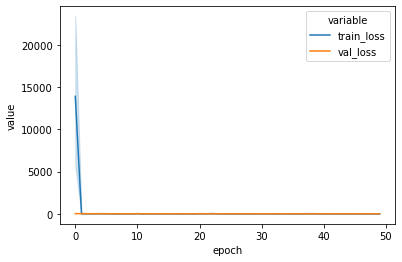

In [9]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
metrics_melt = pd.melt(metrics, id_vars=["epoch", "step"]).dropna()
g = sns.lineplot(x="epoch", y="value", hue="variable", data=metrics_melt)
g.get_figure().savefig(f"{logger.log_dir}/losses.png", dpi=300)

In [10]:
dm.setup("test") # as we predict on the test set
ret = trainer.predict(model, dm)

predictions = torch.cat([batch[0].sum(dim=1) for batch in ret])
values = torch.cat([batch[1].sum(dim=1) for batch in ret])
print(f"Number of predictions : {len(predictions)}")

Predicting: 2500it [00:04, ?it/s]
Number of predictions : 10000


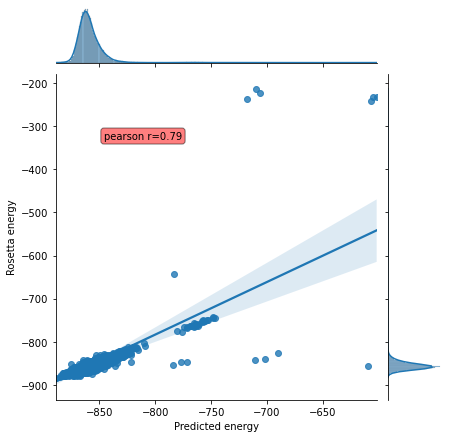

In [23]:
import scipy as sp


g = sns.jointplot(y=values.numpy(), x=predictions.numpy(), ax=ax, kind='reg')
pearson_r = sp.stats.pearsonr(predictions, values)

ax = g.ax_joint
ax.text(0.15, 0.8, f"pearson r={pearson_r[0]:.2f}", 
        horizontalalignment='left',
        bbox=dict(boxstyle="round", facecolor='red', alpha=0.5),
        transform=ax.transAxes)


ax.set_ylabel("Rosetta energy")
ax.set_xlabel("Predicted energy")


pass

In [12]:
pl.__version__

'1.5.3'